# Fundamentals Alpha — Which Fundamentals Predict Future Returns?

**Goal:** Identify which fundamental characteristics (valuation, quality, profitability) predict
forward stock returns over 6-month, 1-year, 2-year, 3-year, and 5-year horizons.

**Data:** `monthly_pe` table — 489K rows, 2,582 tickers, 1986–2026 (monthly snapshots of
fundamental ratios and price). Sector assignments from `company_overview`.

**Features (54):**
- Valuation level: PE, P/FCF, EV/EBITDA, P/S, P/BV, P/TBV, FCF yield, dividend yield
- Yield metrics: earnings yield, FCF yield, EBITDA/EV yield — current, 3yr avg, 5yr avg
- Normalized multiples: CAPE-style 5yr normalized PE, P/FCF, EV/EBITDA, P/S
- Mean-reversion signals: ratio ÷ own 5yr rolling median (>1 = trading at premium)
- Quality / profitability: ROA, ROE, ROIC + their 5yr-rolling premiums
- Growth: trailing 1yr / 3yr / 5yr CAGRs for revenue, earnings, and FCF
- Sector-relative: ratio ÷ sector median for that month (removes sector-level base rate)

**Approach** (mirrors `ibd50_analysis.ipynb`):
1. Compute forward returns from monthly price data
2. EDA — correlation heatmap, quintile return analysis, factor IC
3. XGBoost + SHAP — which features drive returns and in which direction
4. Walk-forward validation — honest out-of-sample performance
5. Live scoring — rank all current tickers by predicted return

---
## Cell 1 — Imports & Config

In [1]:
import sys, warnings
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import spearmanr
from dotenv import load_dotenv
import os

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (13, 5)
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('husl')
pd.set_option('display.float_format', '{:.3f}'.format)
pd.set_option('display.max_columns', None)

ROOT = Path('..').resolve()
sys.path.insert(0, str(ROOT))
load_dotenv(ROOT / '.env', override=True)

from historic_fundamentals import get_pe_stats
from historic_fundamentals.db import HistoricFundamentalsDB

DB_PATH        = os.getenv('HF_DB_PATH', str(ROOT / 'data' / 'historic_fundamentals.duckdb'))
PRICES_DB_PATH = os.getenv('PRICES_DB_PATH', '')

# ── Return horizons: name -> months ahead ─────────────────────────────────────
RETURN_HORIZONS = {
    'ret_6m':  6,
    'ret_1y':  12,
    'ret_2y':  24,
    'ret_3y':  36,
    'ret_5y':  60,
}
RETURN_COLS    = list(RETURN_HORIZONS.keys())
PRIMARY_TARGET = 'ret_1y'   # 1-year horizon is the natural fit for fundamental investing

MIN_VALID            = 200   # minimum rows for a horizon to enter analysis
N_BINS               = 5     # quintiles for EDA
RANDOM_STATE         = 42
WINSOR_CLIP          = 1.5   # clip returns beyond ±150% (was 3.0 — tighter tail control)
SHAP_PRUNE_THRESHOLD = 0.05  # drop features with mean |SHAP| < 5% of top feature score

# ── Risk / methodology controls ───────────────────────────────────────────────
MARKET_CAP_MIN  = 300e6   # $300M minimum — exclude micro-caps (noise + illiquidity)
TC_BPS_ONEWAY   = 10      # one-way transaction cost estimate in basis points
XSEC_ZSCORE     = True    # z-score features within each month cross-section before ML

print('Imports done.')
print('DB:', DB_PATH)
print('Prices DB:', PRICES_DB_PATH or '(not set)')


Imports done.
DB: /home/pedro/projects/fin_import2/data/historic_fundamentals.duckdb
Prices DB: /home/pedro/projects/trade_systems/data/prices.duckdb


---
## Cell 2 — Load monthly_pe Data

In [2]:
conn = duckdb.connect(DB_PATH, read_only=True)
raw  = conn.execute("""
    SELECT ticker, month_end_date, price, shares,
           ttm_revenue, ttm_eps, ttm_fcf,
           pe_ratio,    pe_rolling_5yr_median,
           earnings_yield, earnings_yield_3y_avg, earnings_yield_5y_avg,
           normalized_pe_5y,
           pfcf_ratio,  pfcf_rolling_5yr_median, fcf_yield,
           fcf_yield_3y_avg, fcf_yield_5y_avg, normalized_pfcf_5y,
           ev_ebitda,   ev_ebitda_rolling_5yr_median,
           ebitda_ev_yield, ebitda_ev_yield_3y_avg, ebitda_ev_yield_5y_avg,
           normalized_evebitda_5y,
           ps_ratio,    ps_rolling_5yr_median,    normalized_ps_5y,
           roa,         roa_rolling_5yr_median,
           roe,         roe_rolling_5yr_median,
           roic,        roic_rolling_5yr_median,
           pbv,         pbv_rolling_5yr_median,
           ptbv,        ptbv_rolling_5yr_median,
           dividend_yield,
           ttm_gross_margin,     gross_margin_5y_median,     gross_margin_slope_5y,
           ttm_operating_margin, operating_margin_5y_median,
           operating_margin_change_3y, operating_margin_slope_5y,
           ttm_fcf_margin, fcf_margin_5y_median, fcf_margin_change_3y,
           roa_stability_5y, debt_to_ebitda, interest_coverage
    FROM monthly_pe
    WHERE price > 0
    ORDER BY ticker, month_end_date
""").df()
conn.close()

raw['month_end_date'] = pd.to_datetime(raw['month_end_date'])

print(f'Rows: {len(raw):,}  |  Tickers: {raw["ticker"].nunique():,}')
print(f'Date range: {raw["month_end_date"].min().date()} → {raw["month_end_date"].max().date()}')
raw.head(3)


Rows: 674,001  |  Tickers: 2,653
Date range: 1983-12-31 → 2026-06-30


,ticker,month_end_date,price,shares,ttm_revenue,ttm_eps,ttm_fcf,pe_ratio,pe_rolling_5yr_median,earnings_yield,earnings_yield_3y_avg,earnings_yield_5y_avg,normalized_pe_5y,pfcf_ratio,pfcf_rolling_5yr_median,fcf_yield,fcf_yield_3y_avg,fcf_yield_5y_avg,normalized_pfcf_5y,ev_ebitda,ev_ebitda_rolling_5yr_median,ebitda_ev_yield,ebitda_ev_yield_3y_avg,ebitda_ev_yield_5y_avg,normalized_evebitda_5y,ps_ratio,ps_rolling_5yr_median,normalized_ps_5y,roa,roa_rolling_5yr_median,roe,roe_rolling_5yr_median,roic,roic_rolling_5yr_median,pbv,pbv_rolling_5yr_median,ptbv,ptbv_rolling_5yr_median,dividend_yield,ttm_gross_margin,gross_margin_5y_median,gross_margin_slope_5y,ttm_operating_margin,operating_margin_5y_median,operating_margin_change_3y,operating_margin_slope_5y,ttm_fcf_margin,fcf_margin_5y_median,fcf_margin_change_3y,roa_stability_5y,debt_to_ebitda,interest_coverage
0,A,1999-11-30,26.958,458928571.000,7952000000.000,0.560,1161000000.000,48.139,NaN,0.021,NaN,NaN,NaN,10.656,NaN,0.094,NaN,NaN,NaN,13.462,NaN,0.074,NaN,NaN,NaN,1.556,NaN,NaN,0.052,NaN,0.085,NaN,0.095,NaN,4.094,NaN,4.094,NaN,NaN,0.493,NaN,NaN,0.056,NaN,NaN,NaN,0.146,NaN,NaN,NaN,0.000,9.609
1,A,1999-12-31,49.398,440000000.000,8331000000.000,1.164,1161000000.000,42.452,NaN,0.024,NaN,NaN,NaN,18.721,NaN,0.053,NaN,NaN,NaN,29.332,NaN,0.034,NaN,NaN,NaN,2.609,NaN,NaN,0.094,NaN,0.151,NaN,0.173,NaN,6.427,NaN,6.427,NaN,NaN,1.000,NaN,NaN,0.089,NaN,NaN,NaN,0.139,NaN,NaN,NaN,0.000,NaN
2,A,2000-01-31,42.293,440000000.000,8331000000.000,1.164,895000000.000,36.346,NaN,0.028,NaN,NaN,NaN,20.792,NaN,0.048,NaN,NaN,NaN,25.113,NaN,0.040,NaN,NaN,NaN,2.234,NaN,NaN,0.094,NaN,0.151,NaN,0.173,NaN,5.502,NaN,5.502,NaN,NaN,1.000,NaN,NaN,0.089,NaN,NaN,NaN,0.107,NaN,NaN,NaN,0.000,NaN


---
## Cell 2b — Sector / Industry Assignments

Join the latest `company_overview` sector and industry into `raw` by ticker.
Sector assignments are applied uniformly across all historical months (standard
factor convention — we use today's GICS-equivalent classification throughout history).

In [3]:
# ── Load sector / industry from company_overview ─────────────────────────────
AV_PATH = os.getenv('AV_DB_PATH', str(ROOT / 'data' / 'av_financials.duckdb'))
if not Path(AV_PATH).is_absolute():
    AV_PATH = str(ROOT / AV_PATH)
try:
    av_conn = duckdb.connect(AV_PATH, read_only=True)
    sector_map = av_conn.execute("""
        SELECT ticker, sector, industry
        FROM (
            SELECT ticker, sector, industry,
                   ROW_NUMBER() OVER (PARTITION BY ticker ORDER BY fetch_date DESC) AS rn
            FROM company_overview
            WHERE sector IS NOT NULL AND sector NOT IN ('None', '', 'N/A')
        ) t WHERE rn = 1
    """).df()
    av_conn.close()
except Exception as e:
    sector_map = pd.DataFrame(columns=['ticker', 'sector', 'industry'])
    print(f'Sector assignments unavailable: {e}')

raw = raw.merge(sector_map, on='ticker', how='left')

# ── Market cap filter: exclude micro-caps ─────────────────────────────────────
# Historical market cap = shares_outstanding × month-end price (both in monthly_pe).
# Filter removes illiquid names where factor signals are non-tradeable.
raw['market_cap'] = raw['shares'] * raw['price']
n_before = len(raw)
if MARKET_CAP_MIN > 0:
    raw = raw[raw['market_cap'] >= MARKET_CAP_MIN].copy()
n_after = len(raw)

n_with = raw['sector'].notna().sum()
print(f'Market cap filter (>=${MARKET_CAP_MIN/1e6:.0f}M): {n_before:,} → {n_after:,} rows '
      f'({n_after/n_before:.0%} retained, {raw["ticker"].nunique():,} tickers)')
print(f'Sector assigned: {n_with:,} / {len(raw):,} rows ({n_with/len(raw):.0%})')
print(f'Unique sectors:   {raw["sector"].nunique()}')
print(f'Unique industries:{raw["industry"].nunique()}')
raw[['ticker','sector','industry']].drop_duplicates('ticker').groupby('sector').size().sort_values(ascending=False)


Market cap filter (>=$300M): 674,001 → 489,651 rows (73% retained, 2,582 tickers)
Sector assigned: 489,545 / 489,651 rows (100%)
Unique sectors:   12
Unique industries:147


sector
HEALTHCARE                439
FINANCIAL SERVICES        419
INDUSTRIALS               372
TECHNOLOGY                366
CONSUMER CYCLICAL         286
REAL ESTATE               168
BASIC MATERIALS           130
ENERGY                    122
CONSUMER DEFENSIVE        118
COMMUNICATION SERVICES     93
UTILITIES                  67
NONE                        1
dtype: int64

---
## Cell 3 — Compute Forward Returns

For each (ticker, month T), the forward return at horizon N is:

    ret_N = price[T + N months] / price[T] - 1

We look for a price within ±45 days of the target date. Rows where the future price
is not yet available (too recent) will be NaN — handled in Cell 5.

In [4]:
def compute_forward_returns(df, horizons):
    """
    Add forward return columns using O(n) per-ticker shift.
    Monthly data is aligned to month-end dates so an exact n-month shift
    is equivalent to the previous fuzzy ±45-day merge but uses no extra memory.
    """
    df = df.sort_values(['ticker', 'month_end_date']).reset_index(drop=True).copy()
    for col, months in horizons.items():
        df[col] = (
            df.groupby('ticker')['price']
            .transform(lambda s: s.shift(-months) / s - 1)
        )
    return df

df = compute_forward_returns(raw.copy(), RETURN_HORIZONS)
del raw
import gc; gc.collect()

import psutil, os as _os
print(f'df shape: {df.shape}')
print(f'RAM after forward returns: {psutil.Process(_os.getpid()).memory_info().rss / 1e9:.2f} GB')


df shape: (489651, 60)
RAM after forward returns: 0.59 GB


---
## Cell 3b — Growth Features (Trailing CAGRs)

For each (ticker, month T) compute the trailing growth rates over 1, 3, and 5 years
from the **same month, N years earlier** of `ttm_revenue`, `ttm_eps`, and `ttm_fcf`.
These are backward-looking — no look-ahead bias.

- `rev_cagr_3y = (ttm_revenue_T / ttm_revenue_{T-36mo})^(1/3) - 1`
- Negative bases (loss-making years) produce NaN — handled by feature imputation later

This uses the same self-join pattern as the forward-return computation, but with
a `-N months` offset.

In [5]:
GROWTH_SPECS = {
    'rev':  ('ttm_revenue', [1, 3, 5]),
    'earn': ('ttm_eps',     [1, 3, 5]),
    'fcf':  ('ttm_fcf',     [1, 3, 5]),
}

def add_trailing_cagr(df, base_col, years, prefix):
    """O(n) shift-based CAGR — no self-join needed for monthly data."""
    out_col = f'{prefix}_cagr_{years}y'
    months  = years * 12
    past = df.groupby('ticker')[base_col].transform(lambda s: s.shift(months))
    valid = (past > 0) & (df[base_col] > 0) & past.notna() & df[base_col].notna()
    df[out_col] = np.where(valid, (df[base_col] / past) ** (1.0 / years) - 1, np.nan)
    return df

print('Computing trailing CAGRs...')
for prefix, (base_col, year_list) in GROWTH_SPECS.items():
    for years in year_list:
        df = add_trailing_cagr(df, base_col, years, prefix)

import gc; gc.collect()
import psutil, os as _os
print(f'  done. RAM: {psutil.Process(_os.getpid()).memory_info().rss / 1e9:.2f} GB')


Computing trailing CAGRs...


  done. RAM: 0.62 GB


In [6]:
# ── Cell 3c — Price Momentum ──────────────────────────────────────────────────
# 12-1 month momentum: total return from T-12 months to T-1 month.
# O(n) shift-based — no self-join needed for monthly data.

def add_momentum(df, skip_months=1, lookback_months=12):
    grp = df.groupby('ticker')['price']
    price_t1  = grp.transform(lambda s: s.shift(skip_months))
    price_t12 = grp.transform(lambda s: s.shift(lookback_months))
    valid = (price_t12 > 0) & (price_t1 > 0) & price_t12.notna() & price_t1.notna()
    df['momentum_12_1'] = np.where(valid, price_t1 / price_t12 - 1, np.nan)
    df['momentum_12_1'] = df['momentum_12_1'].clip(-0.99, 10.0)
    return df

print('Computing 12-1 month price momentum...')
df = add_momentum(df)
n_valid = df['momentum_12_1'].notna().sum()
print(f'  momentum_12_1: {n_valid:,} valid  '
      f'median={df.loc[df["momentum_12_1"].notna(), "momentum_12_1"].median()*100:+.1f}%')

import gc; gc.collect()
import psutil, os as _os
print(f'  RAM: {psutil.Process(_os.getpid()).memory_info().rss / 1e9:.2f} GB')


Computing 12-1 month price momentum...


  momentum_12_1: 459,053 valid  median=+9.2%
  RAM: 0.64 GB


---
## Cell 4 — Feature Engineering

Four feature groups:
- **Valuation level** — absolute multiples (PE, P/FCF, EV/EBITDA, P/S, P/BV, P/TBV, FCF yield)
- **Mean-reversion signal** — current multiple ÷ own 5yr rolling median (>1 = premium, <1 = discount)
- **Quality / profitability** — ROA, ROE, ROIC + their 5yr-rolling premiums
- **Sector-relative** — current multiple ÷ sector median for that same month. Values >1 mean the
  stock trades at a premium to its sector peers. This removes the sector-level base rate so the
  model learns "is PE high *for this sector*?" rather than "is PE high absolutely?"

In [7]:
def safe_ratio(a, b, clip=10.0):
    """a / b, clipped to avoid extreme values from near-zero denominators."""
    return (a / b.replace(0, np.nan)).clip(-clip, clip)

# ── Profitability flag ────────────────────────────────────────────────────────
# Binary signal: 1 = currently profitable. Helps model interpret NaN CAGRs
# (loss-making companies have NaN growth features that get median-imputed).
df['is_profitable'] = (df['ttm_eps'] > 0).astype(float)

# ── Mean-reversion premiums ───────────────────────────────────────────────────
df["pe_premium"]   = safe_ratio(df["pe_ratio"],   df["pe_rolling_5yr_median"])
df["pfcf_premium"] = safe_ratio(df["pfcf_ratio"], df["pfcf_rolling_5yr_median"])
df["ev_premium"]   = safe_ratio(df["ev_ebitda"],  df["ev_ebitda_rolling_5yr_median"])
df["ps_premium"]   = safe_ratio(df["ps_ratio"],   df["ps_rolling_5yr_median"])
df["roa_premium"]  = safe_ratio(df["roa"],        df["roa_rolling_5yr_median"])
df["roe_premium"]  = safe_ratio(df["roe"],        df["roe_rolling_5yr_median"])
df["roic_premium"] = safe_ratio(df["roic"],       df["roic_rolling_5yr_median"])
df["pbv_premium"]  = safe_ratio(df["pbv"],        df["pbv_rolling_5yr_median"])
df["ptbv_premium"] = safe_ratio(df["ptbv"],       df["ptbv_rolling_5yr_median"])

# NOTE: goal_discount / goal_upside excluded — look-ahead bias via pe_lt_median.

# ── Sector-relative valuation ─────────────────────────────────────────────────
_SEC_REL = [
    ("pe_ratio",   True,  "pe_sector_rel"),
    ("pfcf_ratio", True,  "pfcf_sector_rel"),
    ("ev_ebitda",  True,  "ev_sector_rel"),
    ("ps_ratio",   True,  "ps_sector_rel"),
    ("roic",       False, "roic_sector_rel"),
    ("roa",        False, "roa_sector_rel"),
]

if "sector" in df.columns and df["sector"].notna().any():
    for src_col, positive_only, out_col in _SEC_REL:
        mask = df["sector"].notna() & df[src_col].notna()
        if positive_only:
            mask = mask & (df[src_col] > 0)
        med = (
            df[mask]
            .groupby(["sector", "month_end_date"])[src_col]
            .median()
            .rename("_med")
            .reset_index()
        )
        tmp = df[["sector", "month_end_date", src_col]].merge(
            med, on=["sector", "month_end_date"], how="left"
        )
        df[out_col] = safe_ratio(
            pd.Series(tmp[src_col].values, index=df.index),
            pd.Series(tmp["_med"].values,  index=df.index),
        )
    sector_rel_cols = [c for _, _, c in _SEC_REL]
    cov = df[sector_rel_cols].notna().mean().mean()
    print(f"Sector-relative features: {len(sector_rel_cols)} cols, avg coverage {cov:.0%}")
else:
    sector_rel_cols = []
    print("Sector column not available — sector-relative features skipped")

FEATURE_COLS = [
    # Valuation level
    "pe_ratio", "pfcf_ratio", "ev_ebitda", "ps_ratio", "pbv", "ptbv",
    "fcf_yield", "dividend_yield",
    # Yield metrics (sign-preserving; negative = loss-making)
    "earnings_yield", "earnings_yield_3y_avg", "earnings_yield_5y_avg",
    "fcf_yield_3y_avg", "fcf_yield_5y_avg",
    "ebitda_ev_yield", "ebitda_ev_yield_3y_avg", "ebitda_ev_yield_5y_avg",
    # Normalized / CAPE-style multiples
    "normalized_pe_5y", "normalized_pfcf_5y", "normalized_evebitda_5y", "normalized_ps_5y",
    # Mean-reversion signals (current / 5yr rolling median)
    "pe_premium", "pfcf_premium", "ev_premium", "ps_premium",
    "pbv_premium", "ptbv_premium",
    # Quality / profitability
    "roa", "roe", "roic",
    "roa_premium", "roe_premium", "roic_premium",
    # Growth (trailing CAGRs — backward-looking, no leakage)
    "rev_cagr_1y",  "rev_cagr_3y",  "rev_cagr_5y",
    "earn_cagr_1y", "earn_cagr_3y", "earn_cagr_5y",
    "fcf_cagr_1y",  "fcf_cagr_3y",  "fcf_cagr_5y",
    # Profitability flag (1=profitable; helps model interpret imputed CAGR NaNs)
    "is_profitable",
    # Margins — level, trend, and leverage
    "ttm_gross_margin", "gross_margin_5y_median", "gross_margin_slope_5y",
    "ttm_operating_margin", "operating_margin_5y_median",
    "operating_margin_change_3y", "operating_margin_slope_5y",
    "ttm_fcf_margin", "fcf_margin_5y_median", "fcf_margin_change_3y",
    "roa_stability_5y", "debt_to_ebitda", "interest_coverage",
    # Price momentum (12-1 month, skips short-term reversal)
    "momentum_12_1",
    # Sector-relative (current multiple / sector median for same month)
] + sector_rel_cols

# WF_FEATURE_COLS is frozen here — Cell 10b SHAP pruning does NOT modify it.
# Walk-forward (Cell 11) always trains on this full set (no look-ahead from SHAP).
# SHAP-pruned models are retrained separately for live scoring only.
WF_FEATURE_COLS = list(FEATURE_COLS)

print(f"Features: {len(FEATURE_COLS)}")
print()
print("Feature coverage (fraction non-null, full dataset):")
coverage = df[FEATURE_COLS].notna().mean().sort_values(ascending=False)
for feat, pct in coverage.items():
    print(f"  {feat:35}: {pct:.0%}")


Sector-relative features: 6 cols, avg coverage 90%
Features: 62

Feature coverage (fraction non-null, full dataset):
  is_profitable                      : 100%
  roa                                : 100%
  roa_sector_rel                     : 100%
  earnings_yield                     : 99%
  ps_ratio                           : 99%
  ttm_operating_margin               : 99%
  ttm_gross_margin                   : 99%
  ps_sector_rel                      : 99%
  ttm_fcf_margin                     : 97%
  pbv                                : 96%
  roe                                : 96%
  fcf_yield                          : 96%
  momentum_12_1                      : 94%
  ebitda_ev_yield                    : 93%
  roic                               : 93%
  roic_sector_rel                    : 93%
  rev_cagr_1y                        : 92%
  earnings_yield_3y_avg              : 92%
  roa_stability_5y                   : 89%
  roa_premium                        : 89%
  normalized_ps_5y  

---
## Cell 5 — Return Target Masking

NaN forward returns mean the future price is not yet available (too recent to have N-month data).
We build a boolean mask per horizon and derive `EDA_TARGETS` automatically.

In [8]:
for col in RETURN_COLS:
    df[col + '_valid'] = df[col].notna()

def get_valid(data, return_col):
    return data[data[return_col + '_valid']].copy()

valid_summary = pd.DataFrame({
    'valid_rows': [df[c + '_valid'].sum() for c in RETURN_COLS],
    'valid_pct':  [df[c + '_valid'].mean() * 100 for c in RETURN_COLS],
    'mean_ret':   [df.loc[df[c + '_valid'], c].mean() * 100 for c in RETURN_COLS],
    'median_ret': [df.loc[df[c + '_valid'], c].median() * 100 for c in RETURN_COLS],
}, index=RETURN_COLS).round(1)

print('Forward return availability and summary:')
print(valid_summary.to_string())

EDA_TARGETS      = [c for c in RETURN_COLS if df[c + '_valid'].sum() >= MIN_VALID]
ML_TARGETS       = EDA_TARGETS
PRIMARY_ML_TARGET = PRIMARY_TARGET if PRIMARY_TARGET in EDA_TARGETS else EDA_TARGETS[0]

print(f'\nEDA / ML targets: {EDA_TARGETS}')
print(f'Primary ML target: {PRIMARY_ML_TARGET}')

Forward return availability and summary:
        valid_rows  valid_pct  mean_ret  median_ret
ret_6m      474246     96.900     8.600       5.300
ret_1y      459053     93.800    16.400      10.100
ret_2y      429453     87.700    33.100      20.300
ret_3y      400990     81.900    49.700      31.100
ret_5y      347909     71.100    93.600      56.700

EDA / ML targets: ['ret_6m', 'ret_1y', 'ret_2y', 'ret_3y', 'ret_5y']
Primary ML target: ret_1y


In [9]:
# ── Cross-Sectional Z-Score for ML ───────────────────────────────────────────
# Standardize each feature within its monthly cross-section before ML training.
# This removes market-level absolute effects (e.g., overall PE at 12x in 2009
# vs 25x in 2021) so the model learns relative cheapness within each period.
# EDA cells (correlation heatmap, IC, quintiles) keep using raw df — rank-based
# methods are unaffected by z-scoring so EDA results remain fully interpretable.

if XSEC_ZSCORE:
    ML_DF = df.copy()
    for col in WF_FEATURE_COLS:
        if col not in ML_DF.columns:
            continue
        ML_DF[col] = (
            ML_DF.groupby('month_end_date')[col]
            .transform(lambda x: (x - x.mean()) / (x.std(ddof=0) + 1e-8))
        )
    print(f'Cross-sectional z-scores applied to {len(WF_FEATURE_COLS)} features → ML_DF.')
    print('EDA cells use raw df (unaffected). ML cells (9, 11, 13) use ML_DF.')
else:
    ML_DF = df
    print('Cross-sectional z-scoring disabled (XSEC_ZSCORE=False). ML_DF = df.')


Cross-sectional z-scores applied to 62 features → ML_DF.
EDA cells use raw df (unaffected). ML cells (9, 11, 13) use ML_DF.


---
## Cell 6 — EDA: Feature Correlation Heatmap

Pearson correlation of each feature with each return horizon.
Green = positive predictor of returns, red = negative.

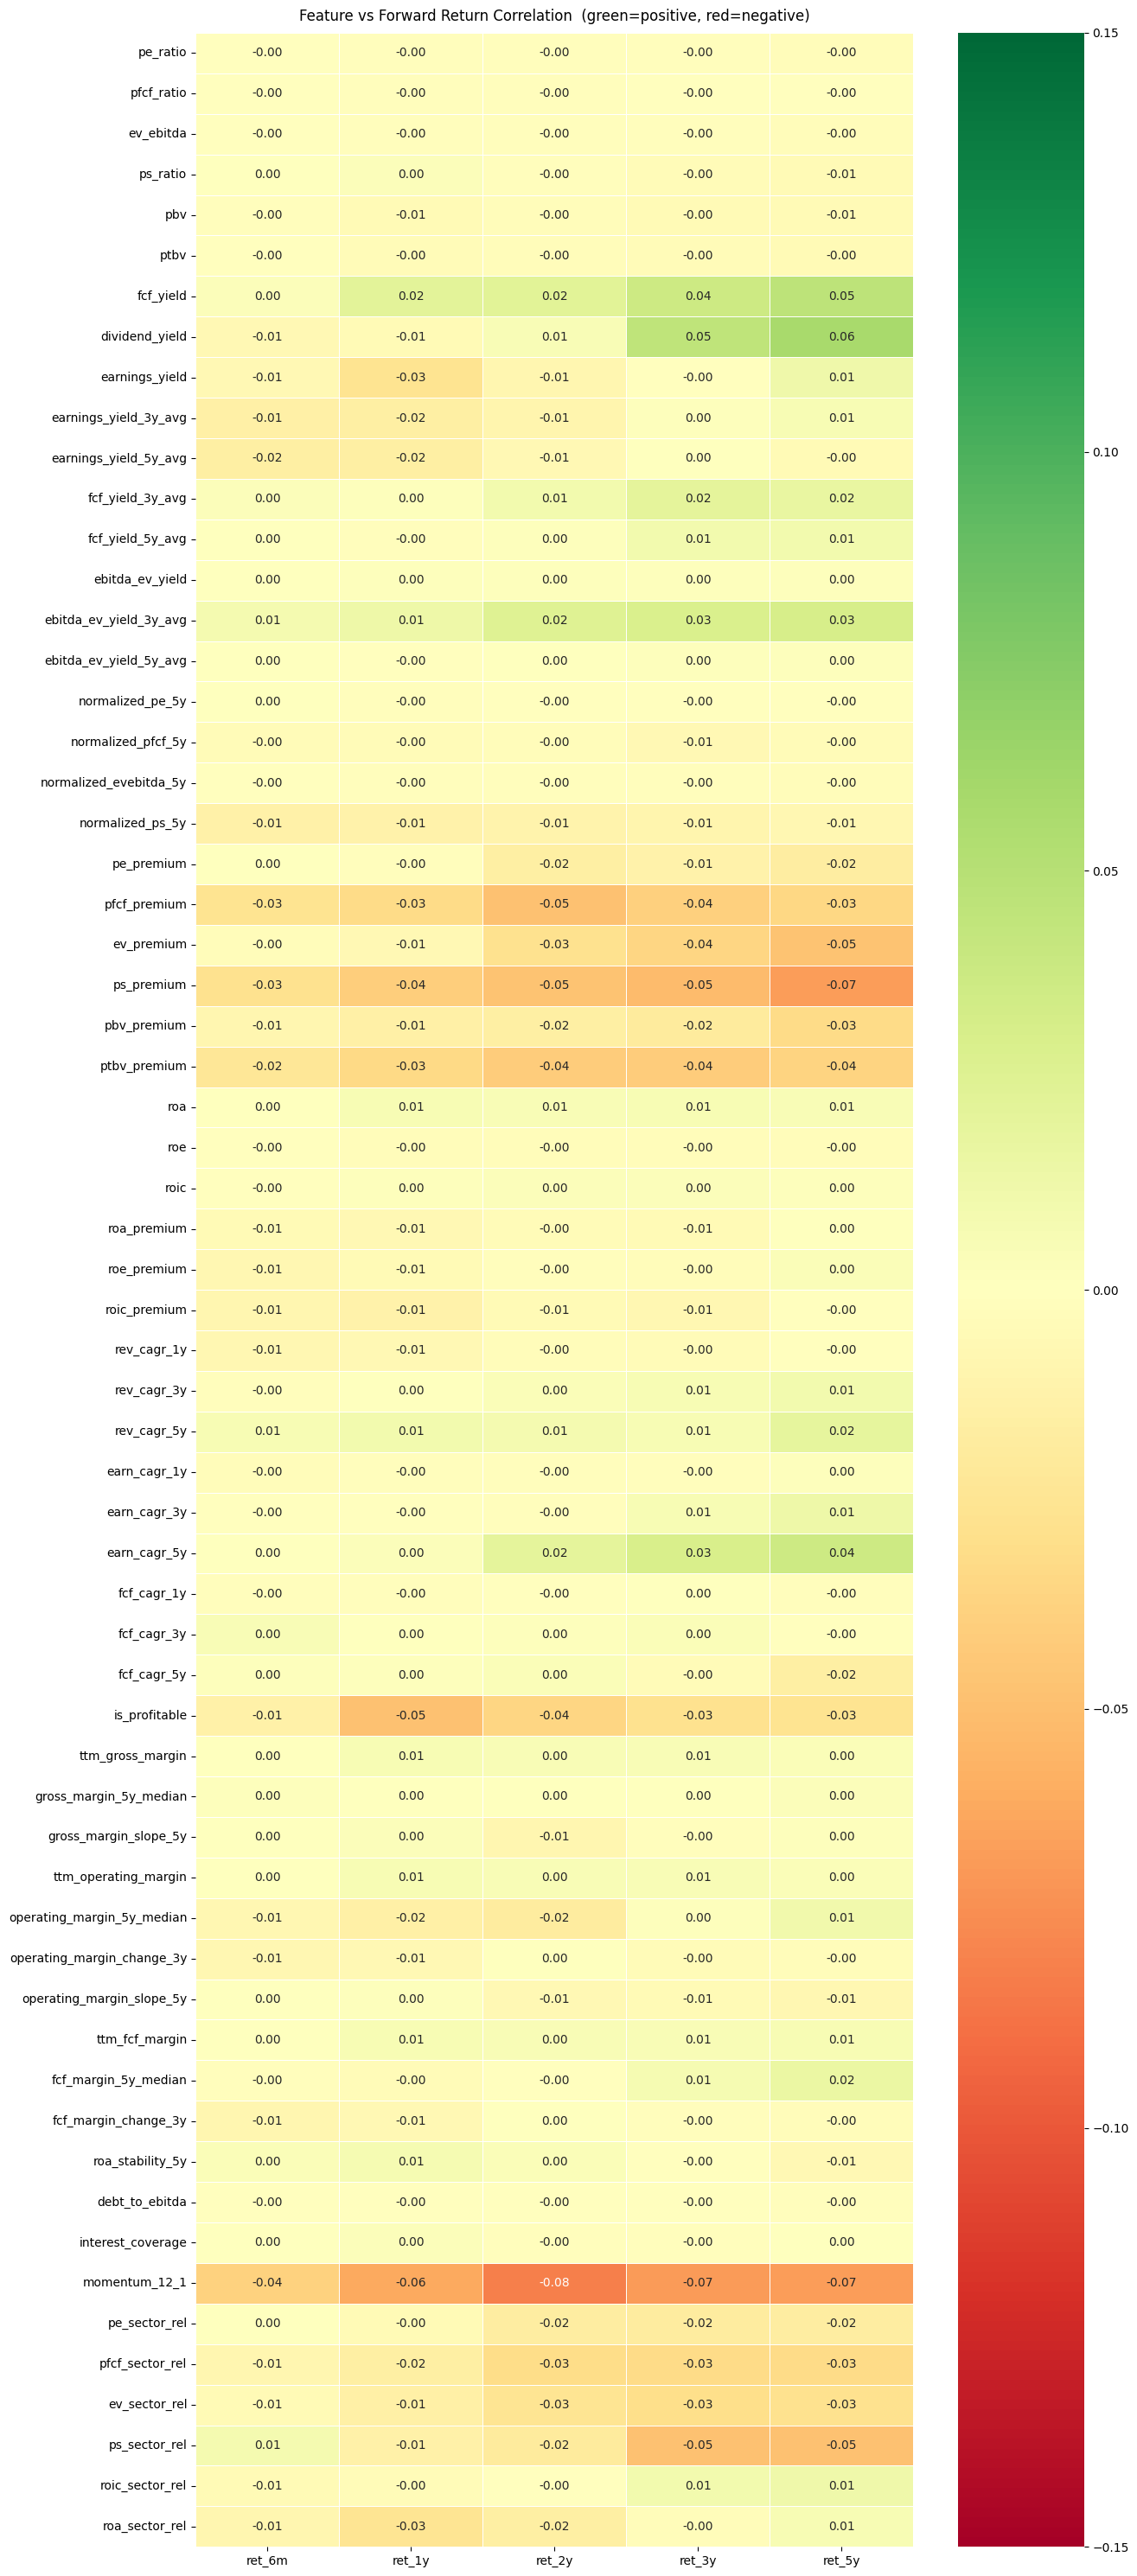

Top features by |correlation| with ret_1y:
momentum_12_1                0.061
is_profitable                0.048
ps_premium                   0.040
ptbv_premium                 0.033
pfcf_premium                 0.032
earnings_yield               0.026
roa_sector_rel               0.025
fcf_yield                    0.022
earnings_yield_3y_avg        0.016
pfcf_sector_rel              0.016
earnings_yield_5y_avg        0.016
operating_margin_5y_median   0.015
pbv_premium                  0.014
ev_sector_rel                0.014
ebitda_ev_yield_3y_avg       0.014
ps_sector_rel                0.014
normalized_ps_5y             0.013
roic_premium                 0.012
rev_cagr_5y                  0.010
roa_stability_5y             0.007
ev_premium                   0.007
roa_premium                  0.007
fcf_margin_change_3y         0.006
operating_margin_change_3y   0.006
roa                          0.006
ttm_operating_margin         0.006
ttm_gross_margin             0.006
ttm_fcf_marg

In [10]:
df_valid_primary = get_valid(df, PRIMARY_ML_TARGET)

corr_targets = [c for c in RETURN_COLS if df[c + '_valid'].sum() >= MIN_VALID]
corr_matrix  = (
    df_valid_primary[FEATURE_COLS + corr_targets]
    .corr()[corr_targets]
    .loc[FEATURE_COLS]
)

fig, ax = plt.subplots(figsize=(len(corr_targets) * 2 + 3, len(FEATURE_COLS) * 0.45 + 2))
sns.heatmap(
    corr_matrix, annot=True, fmt='.2f', center=0,
    cmap='RdYlGn', linewidths=0.4, ax=ax,
    vmin=-0.15, vmax=0.15
)
ax.set_title('Feature vs Forward Return Correlation  (green=positive, red=negative)',
             fontsize=12, pad=10)
plt.tight_layout()
plt.show()

print(f'Top features by |correlation| with {PRIMARY_ML_TARGET}:')
top = corr_matrix[PRIMARY_ML_TARGET].abs().sort_values(ascending=False)
print(top.round(3).to_string())

---
## Cell 7 — EDA: Factor IC (Information Coefficient)

The Information Coefficient (IC) measures how well a feature ranks stocks in order of their
subsequent returns. Computed as the **monthly cross-sectional Spearman rank correlation**
between each feature and the forward return.

- IC > 0 means higher feature value → higher return
- ICIR = mean(IC) / std(IC) — analogous to Sharpe ratio for a factor
- Rule of thumb: |ICIR| > 0.5 is practically significant

Computing monthly IC (this may take ~1-2 minutes)...



Mean monthly IC by feature and horizon (Spearman):
target                      ret_6m  ret_1y  ret_2y  ret_3y  ret_5y
feature                                                           
fcf_yield                    0.043   0.061   0.096   0.116   0.121
dividend_yield               0.048   0.069   0.092   0.100   0.119
ps_ratio                    -0.048  -0.067  -0.095  -0.106  -0.110
normalized_ps_5y            -0.046  -0.064  -0.091  -0.101  -0.108
fcf_yield_3y_avg             0.045   0.064   0.090   0.101   0.103
normalized_pfcf_5y          -0.044  -0.063  -0.085  -0.092  -0.096
pfcf_ratio                  -0.032  -0.050  -0.084  -0.104  -0.109
ps_sector_rel               -0.043  -0.059  -0.081  -0.091  -0.095
fcf_yield_5y_avg             0.042   0.058   0.082   0.093   0.091
pfcf_sector_rel             -0.036  -0.051  -0.076  -0.094  -0.098
normalized_evebitda_5y      -0.035  -0.052  -0.076  -0.079  -0.079
ebitda_ev_yield              0.031   0.044   0.071   0.084   0.084
ev_ebitda 

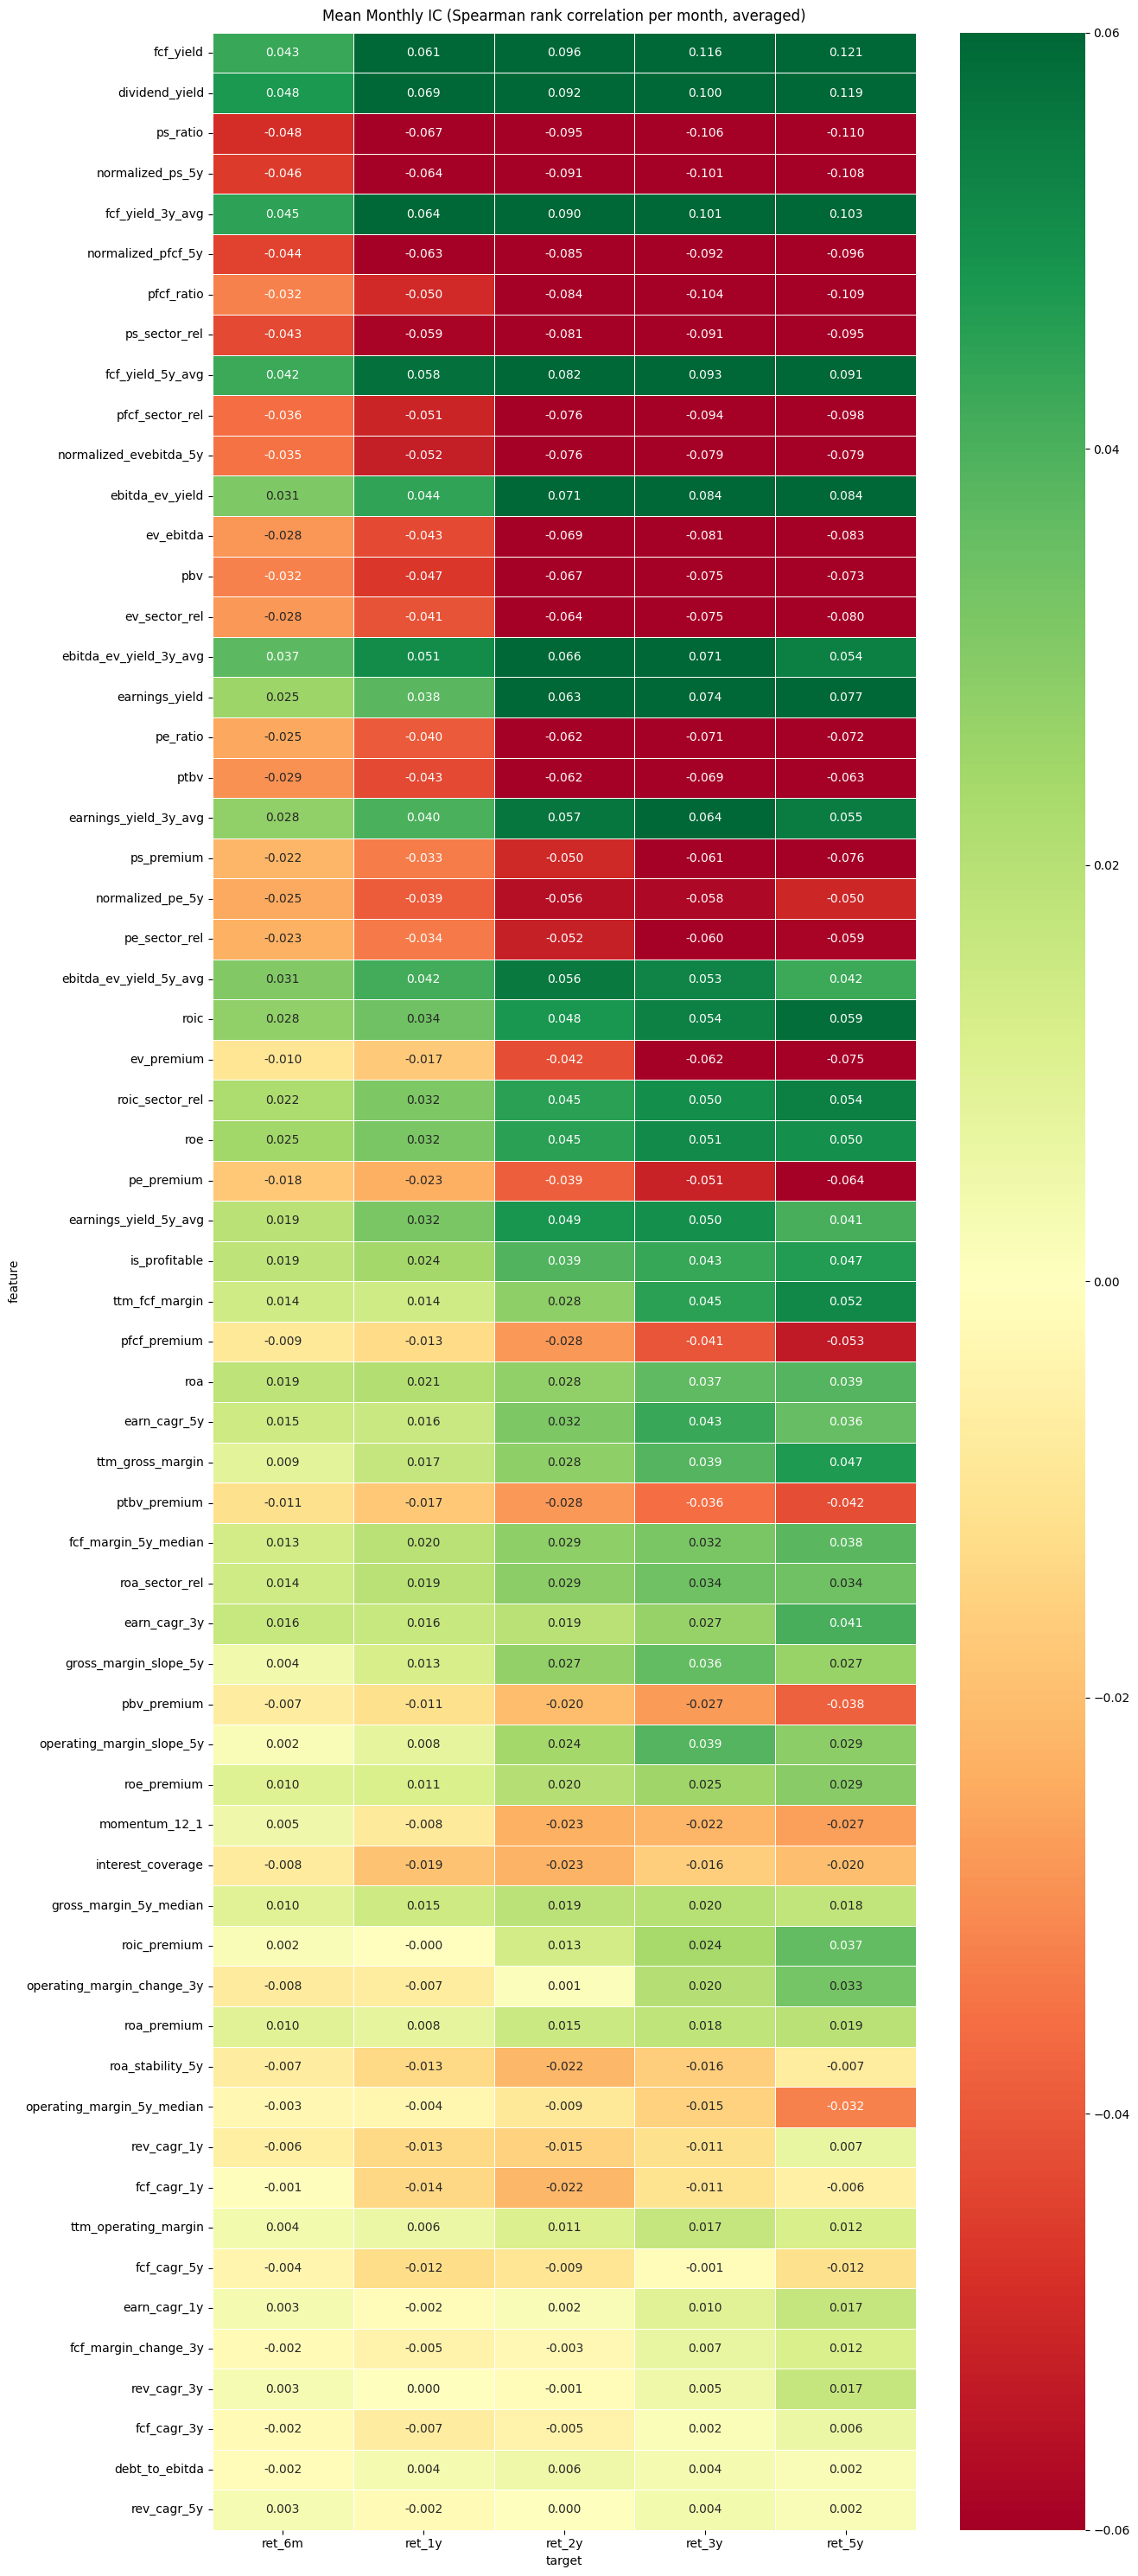


ICIR for ret_1y (|ICIR|>0.5 = practically significant):
feature
pfcf_sector_rel              -0.599
fcf_yield_3y_avg              0.559
fcf_yield                     0.551
ps_sector_rel                -0.547
dividend_yield                0.526
normalized_pfcf_5y           -0.518
fcf_yield_5y_avg              0.518
ps_ratio                     -0.501
normalized_ps_5y             -0.487
ebitda_ev_yield_3y_avg        0.468
normalized_evebitda_5y       -0.425
ev_sector_rel                -0.420
roic_sector_rel               0.419
pfcf_ratio                   -0.418
roic                          0.399
ebitda_ev_yield_5y_avg        0.379
pe_sector_rel                -0.377
ebitda_ev_yield               0.350
ev_ebitda                    -0.340
earnings_yield_3y_avg         0.333
pbv                          -0.325
pe_ratio                     -0.321
ptbv                         -0.306
roe                           0.305
earnings_yield                0.302
normalized_pe_5y             -0.298

In [11]:
def compute_ic(data, features, targets, min_stocks=20):
    """Monthly cross-sectional Spearman IC for each (feature, target) pair."""
    records = []
    for target in targets:
        sub = get_valid(data, target)
        for month, mdf in sub.groupby('month_end_date'):
            if len(mdf) < min_stocks:
                continue
            for feat in features:
                valid = mdf[[feat, target]].dropna()
                if len(valid) < min_stocks:
                    continue
                ic, _ = spearmanr(valid[feat], valid[target])
                records.append({'month': month, 'feature': feat, 'target': target, 'ic': ic})
    return pd.DataFrame(records)

print('Computing monthly IC (this may take ~1-2 minutes)...')
ic_df = compute_ic(df, FEATURE_COLS, EDA_TARGETS)

ic_summary = (
    ic_df.groupby(['feature', 'target'])['ic']
    .agg(mean_ic='mean', std_ic='std', months='count')
    .reset_index()
)
ic_summary['icir'] = ic_summary['mean_ic'] / ic_summary['std_ic']

# Pivot to show mean IC per (feature, target)
ic_pivot = ic_summary.pivot(index='feature', columns='target', values='mean_ic')
ic_pivot = ic_pivot.reindex(columns=EDA_TARGETS)
ic_pivot['abs_mean'] = ic_pivot.abs().mean(axis=1)
ic_pivot = ic_pivot.sort_values('abs_mean', ascending=False).drop(columns='abs_mean')

print('\nMean monthly IC by feature and horizon (Spearman):')
print(ic_pivot.round(3).to_string())

# Heatmap
fig, ax = plt.subplots(figsize=(len(EDA_TARGETS) * 2 + 3, len(FEATURE_COLS) * 0.45 + 2))
sns.heatmap(
    ic_pivot, annot=True, fmt='.3f', center=0,
    cmap='RdYlGn', linewidths=0.4, ax=ax,
    vmin=-0.06, vmax=0.06
)
ax.set_title('Mean Monthly IC (Spearman rank correlation per month, averaged)', fontsize=12, pad=10)
plt.tight_layout()
plt.show()

# ICIR for primary target
icir_primary = (
    ic_summary[ic_summary['target'] == PRIMARY_ML_TARGET]
    .set_index('feature')['icir']
    .sort_values(key=abs, ascending=False)
)
print(f'\nICIR for {PRIMARY_ML_TARGET} (|ICIR|>0.5 = practically significant):')
print(icir_primary.round(3).to_string())

---
## Cell 8 — EDA: Quintile Return Analysis

For each feature, split stocks into 5 equal-frequency buckets (quintiles) and compare
average forward returns. A monotonic pattern (Q1 < Q2 < Q3 < Q4 < Q5 or vice versa)
signals a robust factor.

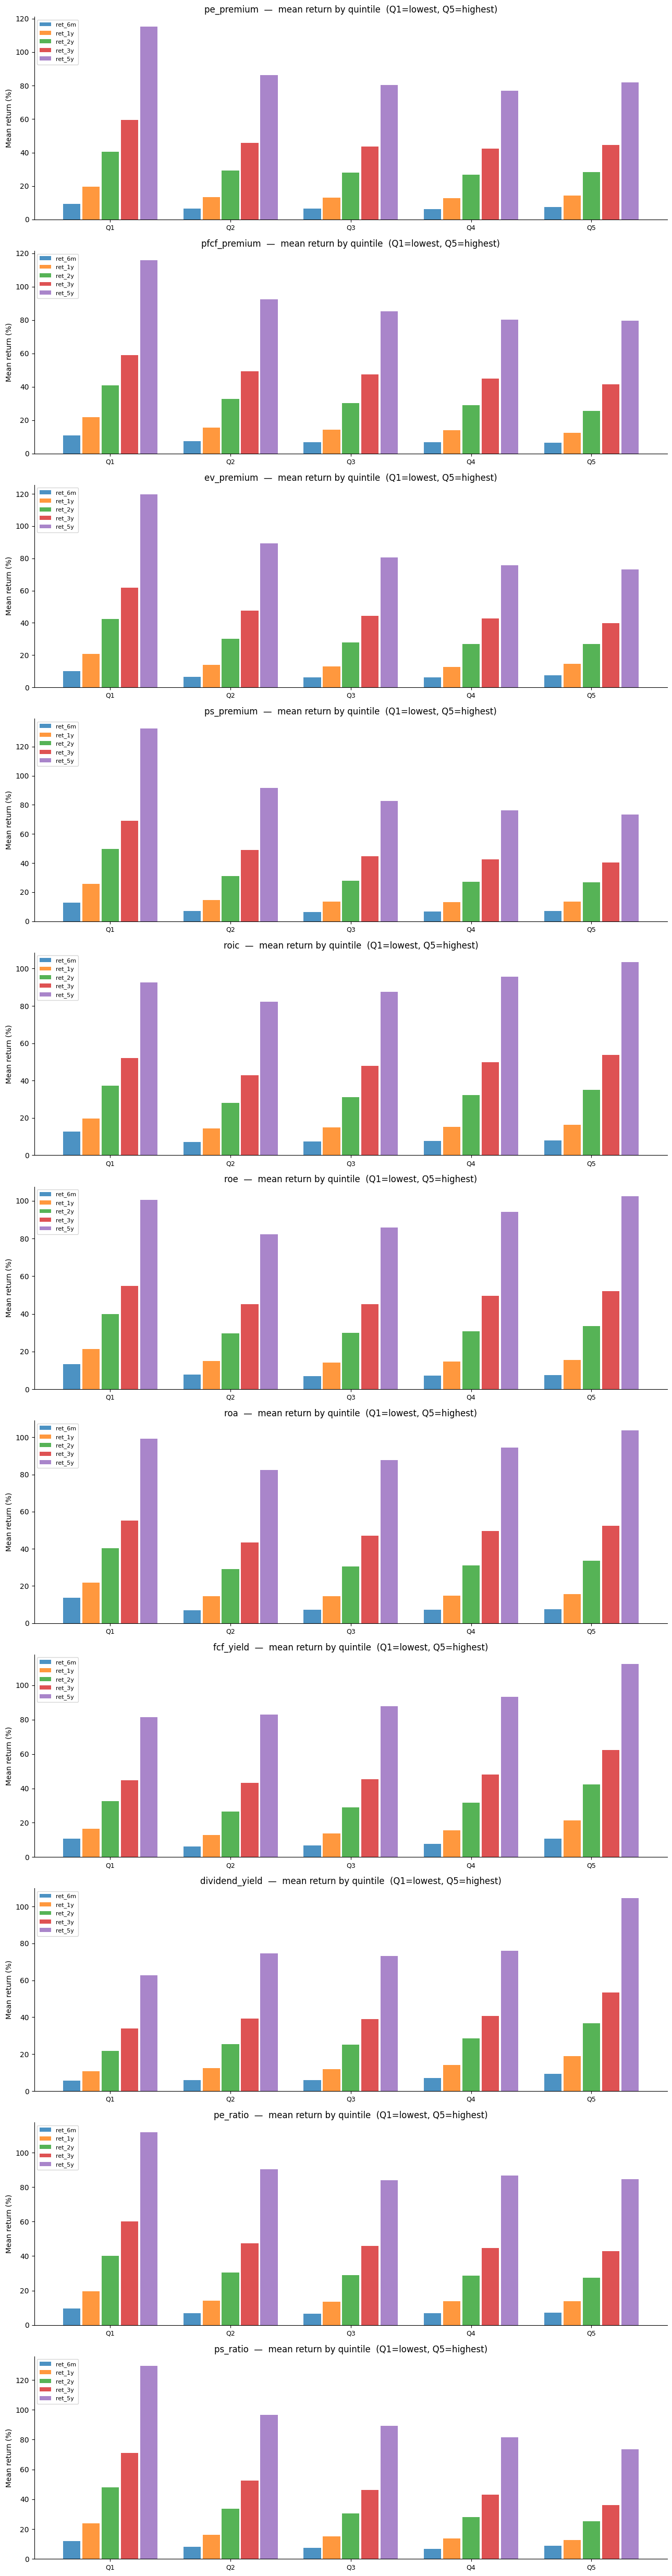

In [12]:
KEY_FEATURES = [
    'pe_premium', 'pfcf_premium', 'ev_premium', 'ps_premium',
    'roic', 'roe', 'roa',
    'fcf_yield', 'dividend_yield',
    'pe_ratio', 'ps_ratio',
]

def quintile_returns(data, feature, targets, n_bins=5):
    """Mean return by quintile for one feature across all targets."""
    rows = {}
    for target in targets:
        sub = get_valid(data, target)[[feature, target]].dropna()
        if len(sub) < 100:
            continue
        sub['bucket'] = pd.qcut(sub[feature], q=n_bins, labels=False, duplicates='drop')
        rows[target] = sub.groupby('bucket')[target].mean() * 100
    return pd.DataFrame(rows) if rows else pd.DataFrame()

n_feats   = len(KEY_FEATURES)
n_targets = len(EDA_TARGETS)
fig, axes = plt.subplots(n_feats, 1, figsize=(13, 4.5 * n_feats))
if n_feats == 1:
    axes = [axes]

colors = plt.cm.tab10.colors

for ax, feat in zip(axes, KEY_FEATURES):
    qt = quintile_returns(df, feat, EDA_TARGETS, N_BINS)
    if qt.empty:
        ax.set_title(f'{feat}  (insufficient data)')
        continue
    x = np.arange(len(qt))
    width = 0.8 / max(len(EDA_TARGETS), 1)
    for i, target in enumerate(EDA_TARGETS):
        if target not in qt.columns:
            continue
        ax.bar(x + i * width, qt[target], width=width * 0.9,
               label=target, color=colors[i % len(colors)], alpha=0.8)
    ax.axhline(0, color='black', linewidth=0.6)
    ax.set_xticks(x + width * (n_targets - 1) / 2)
    ax.set_xticklabels([f'Q{i+1}' for i in range(len(qt))], fontsize=9)
    ax.set_ylabel('Mean return (%)')
    ax.set_title(f'{feat}  —  mean return by quintile  (Q1=lowest, Q5=highest)')
    ax.legend(fontsize=8, loc='upper left')

plt.tight_layout()
plt.show()

---
## Cell 9 — ML: XGBoost Feature Importance

One XGBoost regressor per return horizon. SHAP values reveal which features drive
predictions and in which direction.

In [13]:
from xgboost import XGBRegressor
import shap
from tqdm.auto import tqdm

MIN_ROWS_TO_TRAIN = 500

def get_xgb_params(n_rows):
    """Scale regularisation with dataset size."""
    if n_rows < 2_000:
        return dict(n_estimators=100, max_depth=3, learning_rate=0.05,
                    subsample=0.8, colsample_bytree=0.8, min_child_weight=20)
    return dict(n_estimators=400, max_depth=4, learning_rate=0.02,
                subsample=0.8, colsample_bytree=0.8, min_child_weight=20)

models     = {}   # {target: fitted XGBRegressor on WF_FEATURE_COLS (z-scored)}
ml_datasets = {}  # {target: (X, y)}

print('Training XGBoost models on cross-sectionally z-scored features (ML_DF)...')
print(f'{"Horizon":<12} {"Rows":>8}  {"Features":>10}  Status')
print('-' * 50)

for target in tqdm(ML_TARGETS, desc="Training horizons"):
    sub = get_valid(ML_DF, target)[WF_FEATURE_COLS + [target, 'month_end_date', 'ticker']]
    sub = sub.dropna(subset=[target])

    # Fill feature NaNs with column median (no leakage — done per-target, pre-split)
    X = sub[WF_FEATURE_COLS].fillna(sub[WF_FEATURE_COLS].median())
    y = sub[target]

    if len(X) < MIN_ROWS_TO_TRAIN:
        print(f'{target:<12} {len(X):>8}  skipped (< {MIN_ROWS_TO_TRAIN} rows)')
        continue

    params = get_xgb_params(len(X))
    model  = XGBRegressor(**params, random_state=RANDOM_STATE, verbosity=0)
    model.fit(X, y)

    models[target]      = model
    ml_datasets[target] = (X.values, y.values)

    r2 = 1 - np.sum((y - model.predict(X))**2) / np.sum((y - y.mean())**2)
    print(f'{target:<12} {len(X):>8}  {len(WF_FEATURE_COLS):>10}  R²={r2:.3f}  (in-sample)')

PRIMARY_ML_TARGET = PRIMARY_TARGET if PRIMARY_TARGET in models else next(
    (t for t in ML_TARGETS if t in models), None
)
print(f'\nPrimary target for walk-forward: {PRIMARY_ML_TARGET}')


Training XGBoost models on cross-sectionally z-scored features (ML_DF)...
Horizon          Rows    Features  Status
--------------------------------------------------


Training horizons:   0%|          | 0/5 [00:00<?, ?it/s]

Training horizons:  20%|██        | 1/5 [00:05<00:21,  5.45s/it]

ret_6m         474246          62  R²=0.437  (in-sample)


Training horizons:  40%|████      | 2/5 [00:09<00:14,  4.82s/it]

...

Training horizons:  80%|████████  | 4/5 [00:22<00:05,  5.85s/it]

ret_3y         400990          62  R²=0.178  (in-sample)


Training horizons: 100%|██████████| 5/5 [00:26<00:00,  5.06s/it]

Training horizons: 100%|██████████| 5/5 [00:26<00:00,  5.22s/it]

ret_5y         347909          62  R²=0.177  (in-sample)

Primary target for walk-forward: ret_1y


---
## Cell 10 — SHAP Feature Importance Plots

Bar chart: which features matter most (magnitude).  
Beeswarm: direction of effect (high feature value → positive or negative return?).

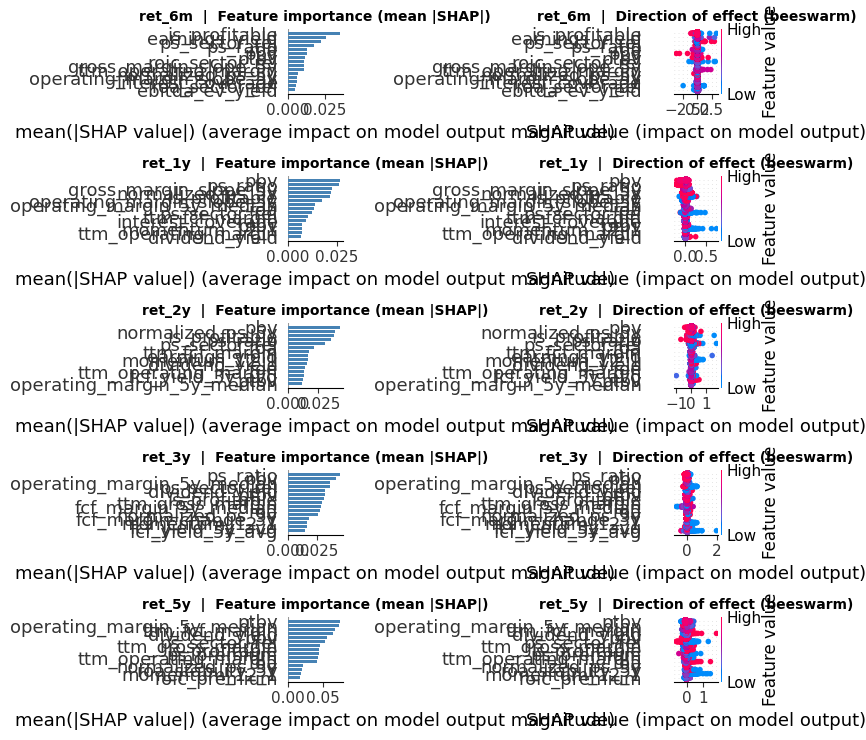


Consolidated SHAP importance across all horizons (top 15):
                            ret_6m  ret_1y  ret_2y  ret_3y  ret_5y  mean
pbv                          0.013   0.027   0.043   0.041   0.056 0.036
is_profitable                0.035   0.021   0.037   0.031   0.045 0.034
ps_sector_rel                0.022   0.013   0.030   0.036   0.053 0.031
ptbv                         0.012   0.007   0.013   0.032   0.074 0.028
ps_ratio                     0.018   0.026   0.035   0.045   0.014 0.028
operating_margin_5y_median   0.001   0.014   0.012   0.036   0.072 0.027
dividend_yield               0.000   0.007   0.016   0.032   0.064 0.024
roa                          0.013   0.013   0.021   0.028   0.042 0.023
normalized_ps_5y             0.007   0.022   0.039   0.026   0.022 0.023
ttm_fcf_margin               0.004   0.010   0.018   0.003   0.067 0.021
ttm_gross_margin             0.001   0.002   0.009   0.029   0.046 0.017
ttm_operating_margin         0.011   0.007   0.013   0.005   0.0

In [14]:
if not models:
    print('No models trained. Run Cell 9 first.')
else:
    trained = list(models.keys())
    fig, axes = plt.subplots(len(trained), 2, figsize=(16, 5.5 * len(trained)))
    if len(trained) == 1:
        axes = [axes]

    shap_importance = {}

    for row_idx, target in enumerate(trained):
        model_t = models[target]
        X_t, y_t = ml_datasets[target]

        sample_size = min(5_000, len(X_t))
        idx = np.random.RandomState(RANDOM_STATE).choice(len(X_t), sample_size, replace=False)
        X_sample = X_t[idx]

        explainer   = shap.TreeExplainer(model_t)
        shap_values = explainer.shap_values(X_sample)

        shap_importance[target] = pd.Series(
            np.abs(shap_values).mean(axis=0),
            index=WF_FEATURE_COLS  # models trained on WF_FEATURE_COLS
        ).sort_values(ascending=False)

        ax_bar = axes[row_idx][0]
        plt.sca(ax_bar)
        shap.summary_plot(shap_values, X_sample, feature_names=WF_FEATURE_COLS,
                          plot_type='bar', show=False, max_display=15, color='steelblue')
        ax_bar.set_title(f'{target}  |  Feature importance (mean |SHAP|)',
                         fontsize=10, fontweight='bold')

        ax_bee = axes[row_idx][1]
        plt.sca(ax_bee)
        shap.summary_plot(shap_values, X_sample, feature_names=WF_FEATURE_COLS,
                          show=False, max_display=15)
        ax_bee.set_title(f'{target}  |  Direction of effect (beeswarm)',
                         fontsize=10, fontweight='bold')

    plt.tight_layout()
    plt.show()

    imp_df = pd.DataFrame(shap_importance).round(5)
    imp_df['mean'] = imp_df.mean(axis=1)
    imp_df = imp_df.sort_values('mean', ascending=False)
    print('\nConsolidated SHAP importance across all horizons (top 15):')
    print(imp_df.head(15).to_string())


---
## Cell 10b — SHAP-based Feature Pruning

Drop features whose mean |SHAP| (averaged across all trained horizons) falls below
`SHAP_PRUNE_THRESHOLD × top_feature_score`. Then retrain all models on the pruned
feature set so Cell 11 walk-forward and Cell 13 live scoring are consistent.

In [15]:
# ── Cell 10b — SHAP-based Feature Pruning (for live scoring only) ─────────────
#
# Drop features whose mean |SHAP| < SHAP_PRUNE_THRESHOLD × top-feature score.
# IMPORTANT: WF_FEATURE_COLS is NOT modified here.
#   - Walk-forward (Cell 11) trains on the full WF_FEATURE_COLS — no look-ahead.
#   - SHAP pruning uses the full-sample SHAP, so it has seen all history.
#     Using it for walk-forward would leak future information into feature selection.
#   - shap_models are trained on SHAP_FEATURE_COLS on the full history and are
#     appropriate for live scoring only (no hold-out set, so no leakage issue).

if not shap_importance:
    print('No SHAP values. Run Cell 10 first.')
    SHAP_FEATURE_COLS = list(WF_FEATURE_COLS)
    shap_models = dict(models)
else:
    imp_mean  = pd.DataFrame(shap_importance).mean(axis=1)
    threshold = imp_mean.max() * SHAP_PRUNE_THRESHOLD

    SHAP_FEATURE_COLS = [f for f in WF_FEATURE_COLS if imp_mean.get(f, 0.0) >= threshold]
    dropped = [f for f in WF_FEATURE_COLS if f not in SHAP_FEATURE_COLS]

    print(f'Features: {len(WF_FEATURE_COLS)} → {len(SHAP_FEATURE_COLS)}  '
          f'(threshold = {SHAP_PRUNE_THRESHOLD:.0%} × top = {threshold:.5f})')
    if dropped:
        print(f'\nDropped ({len(dropped)}): {dropped}')

    # Free original full-feature models before retraining to save RAM
    import gc as _gc
    _model_targets = [t for t in list(ML_TARGETS) if t in models]
    del models
    _gc.collect()

    # Free SHAP arrays — no longer needed for retraining
    del shap_importance
    _gc.collect()

    # Cap to 200K most-recent rows for live-scoring models (memory)
    _MAX_ROWS = 200_000
    ML_DF_sub = ML_DF.sort_values('month_end_date').tail(_MAX_ROWS) if len(ML_DF) > _MAX_ROWS else ML_DF
    del ML_DF
    _gc.collect()

    print(f'\nRetraining shap_models on {len(SHAP_FEATURE_COLS)} pruned features '
          f'({len(ML_DF_sub):,} rows, capped for memory)...')
    shap_models = {}
    for target in _model_targets:
        sub = get_valid(ML_DF_sub, target)[SHAP_FEATURE_COLS + [target]].dropna(subset=[target])
        X   = sub[SHAP_FEATURE_COLS].fillna(sub[SHAP_FEATURE_COLS].median())
        y   = sub[target]
        params = get_xgb_params(len(X))
        model  = XGBRegressor(**params, random_state=RANDOM_STATE, verbosity=0)
        model.fit(X, y)
        shap_models[target] = model
        r2 = 1 - np.sum((y - model.predict(X)) ** 2) / np.sum((y - y.mean()) ** 2)
        print(f'  {target:<10} features={len(SHAP_FEATURE_COLS):>3}  R²={r2:.3f}')
        _gc.collect()

    del ML_DF_sub
    _gc.collect()
    print(f'\nshap_models ready ({len(SHAP_FEATURE_COLS)} features) — used by Cell 13 live scoring.')
    print(f'Walk-forward (Cell 11) still uses WF_FEATURE_COLS ({len(WF_FEATURE_COLS)}) — no leakage.')


import gc; gc.collect()
import psutil, os as _os; print(f'RAM after SHAP: {psutil.Process(_os.getpid()).memory_info().rss / 1e9:.2f} GB')

Features: 62 → 48  (threshold = 5% × top = 0.00180)

Dropped (14): ['pfcf_ratio', 'normalized_pe_5y', 'normalized_pfcf_5y', 'normalized_evebitda_5y', 'pe_premium', 'pfcf_premium', 'ev_premium', 'pbv_premium', 'ptbv_premium', 'roa_premium', 'earn_cagr_1y', 'fcf_cagr_1y', 'fcf_cagr_3y', 'pe_sector_rel']



Retraining shap_models on 48 pruned features (200,000 rows, capped for memory)...


  ret_6m     features= 48  R²=0.220


  ret_1y     features= 48  R²=0.296


  ret_2y     features= 48  R²=0.358


  ret_3y     features= 48  R²=0.403


  ret_5y     features= 48  R²=0.432

shap_models ready (48 features) — used by Cell 13 live scoring.
Walk-forward (Cell 11) still uses WF_FEATURE_COLS (62) — no leakage.


RAM after SHAP: 4.18 GB


---
## Cell 11 — Walk-Forward Validation

Proper time-series validation: train on all months up to T, predict month T+1.
Run for **1y, 2y, 3y, and 5y** horizons. Three benchmarks per horizon:
- **ML top-20%**: stocks ranked highest by model prediction
- **Universe equal-weight**: all stocks with valid data
- **SPY**: S&P 500 ETF forward return over the same horizon

In [16]:
# Free large objects before walk-forward to reclaim memory
import gc
try:
    del models       # full-feature models replaced by shap_models
except NameError: pass
try:
    del ML_DF        # z-scored copy of df — no longer needed
except NameError: pass
gc.collect()
import psutil, os as _os
print(f'RAM before walk-forward: {psutil.Process(_os.getpid()).memory_info().rss / 1e9:.2f} GB')


RAM before walk-forward: 4.18 GB


In [17]:
from sklearn.metrics import r2_score as sk_r2
from tqdm.auto import tqdm

WF_HORIZONS      = [t for t in ['ret_1y'] if t in shap_models]  # limit to primary for memory
MIN_TRAIN_MONTHS = 60
TOP_DECILE_PCT   = 0.20

def newey_west_icir(ic_series, lags):
    """IC mean / Newey-West HAC std error — corrects for overlapping return windows."""
    ic = np.array(ic_series.dropna())
    if len(ic) < lags + 2:
        return np.nan
    ic_dm = ic - ic.mean()
    n = len(ic_dm)
    total = np.dot(ic_dm, ic_dm) / n
    for l in range(1, lags + 1):
        gamma_l = np.dot(ic_dm[l:], ic_dm[:-l]) / n
        total  += 2 * (1 - l / (lags + 1)) * gamma_l  # Bartlett kernel
    nw_std = np.sqrt(max(total, 1e-12))
    return ic.mean() / nw_std

# ── Load SPY forward returns ──────────────────────────────────────────────────
spy_fwd = {}
if PRICES_DB_PATH:
    try:
        spy_conn = duckdb.connect(PRICES_DB_PATH, read_only=True)
        spy_raw  = spy_conn.execute("""
            SELECT
                (date_trunc('month', date) + interval '1 month' - interval '1 day')::DATE
                    AS month_end_date,
                LAST(adj_close ORDER BY date) AS price
            FROM etf_prices
            WHERE ticker = 'SPY'
            GROUP BY date_trunc('month', date)
            ORDER BY month_end_date
        """).df()
        spy_conn.close()
        spy_raw['ticker']         = 'SPY'
        spy_raw['month_end_date'] = pd.to_datetime(spy_raw['month_end_date'])
        spy_df = compute_forward_returns(spy_raw, RETURN_HORIZONS)
        for col in RETURN_COLS:
            spy_fwd[col] = {
                pd.Timestamp(k): v
                for k, v in spy_df.set_index('month_end_date')[col].dropna().items()
            }
        print(f'SPY loaded: {len(spy_raw):,} months')
    except Exception as e:
        print(f'SPY benchmark unavailable: {e}')
else:
    print('PRICES_DB_PATH not set — SPY benchmark skipped')

# ── Walk-forward per horizon ──────────────────────────────────────────────────
wf_results_all = {}

for WF_TARGET in tqdm(WF_HORIZONS, desc="WF horizons", position=0):
    wf_cols     = WF_FEATURE_COLS + [WF_TARGET, 'month_end_date', 'ticker']
    ml_dated_wf = get_valid(df, WF_TARGET)[wf_cols].copy().dropna(subset=[WF_TARGET])
    dates_sorted = sorted(ml_dated_wf['month_end_date'].unique())
    n_test  = len(dates_sorted) - MIN_TRAIN_MONTHS
    nw_lags = RETURN_HORIZONS[WF_TARGET] - 1  # lag = horizon months - 1

    print(f'\n--- {WF_TARGET}  ({len(dates_sorted)} months total, {n_test} test months) ---')
    if n_test < 12:
        print('  Insufficient test months — skipping')
        continue

    wf_results   = []
    prev_top_tix = set()

    for i in tqdm(range(MIN_TRAIN_MONTHS, len(dates_sorted)),
                  desc=f"{WF_TARGET}", leave=False, position=1):
        train_dates = dates_sorted[:i]
        test_date   = dates_sorted[i]

        train = ml_dated_wf[ml_dated_wf['month_end_date'].isin(train_dates)]
        test  = ml_dated_wf[ml_dated_wf['month_end_date'] == test_date].copy()
        if len(test) < 5:
            continue

        X_tr = train[WF_FEATURE_COLS].fillna(train[WF_FEATURE_COLS].median())
        y_tr = train[WF_TARGET]
        X_te = test[WF_FEATURE_COLS].fillna(train[WF_FEATURE_COLS].median())
        y_te = test[WF_TARGET]

        params   = {**get_xgb_params(len(X_tr)),
                    'n_estimators': 100, 'n_jobs': -1, 'tree_method': 'hist'}
        wf_model = XGBRegressor(**params, random_state=RANDOM_STATE, verbosity=0)
        wf_model.fit(X_tr, y_tr)

        preds        = wf_model.predict(X_te)
        test         = test.copy()
        test['pred'] = preds

        n_top     = max(1, int(len(test) * TOP_DECILE_PCT))
        top_rows  = test.nlargest(n_top, 'pred')
        top_tix   = set(top_rows['ticker'])
        top_ret   = top_rows[WF_TARGET].mean()
        bench_ret = y_te.mean()
        spy_ret   = spy_fwd.get(WF_TARGET, {}).get(pd.Timestamp(test_date), np.nan)
        ic, _     = spearmanr(preds, y_te)

        # Transaction cost: actual turnover × one-way cost
        turnover        = 1 - len(top_tix & prev_top_tix) / len(top_tix) if prev_top_tix else 1.0
        tc_cost         = turnover * TC_BPS_ONEWAY / 10_000
        tc_adj_top_ret  = top_ret - tc_cost
        prev_top_tix    = top_tix

        wf_results.append({
            'month':              test_date,
            'train_months':       i,
            'n_stocks':           len(test),
            'top_ret':            top_ret,
            'tc_adj_top_ret':     tc_adj_top_ret,
            'bench_ret':          bench_ret,
            'spy_ret':            spy_ret,
            'excess_vs_universe': top_ret - bench_ret,
            'tc_adj_excess':      tc_adj_top_ret - bench_ret,
            'excess_vs_spy':      top_ret - spy_ret if not np.isnan(spy_ret) else np.nan,
            'monthly_ic':         ic,
            'turnover':           turnover,
        })

    wf_df = pd.DataFrame(wf_results)
    wf_results_all[WF_TARGET] = wf_df

    import gc as _wfgc; del ml_dated_wf, wf_results; _wfgc.collect()

    spy_mean     = wf_df['spy_ret'].mean()
    ex_spy       = wf_df['excess_vs_spy'].mean()
    raw_icir     = wf_df['monthly_ic'].mean() / wf_df['monthly_ic'].std()
    nw_icir      = newey_west_icir(wf_df['monthly_ic'], lags=nw_lags)
    win_rate     = (wf_df['excess_vs_universe'] > 0).mean()
    avg_turnover = wf_df['turnover'].mean()
    avg_tc_mo    = avg_turnover * TC_BPS_ONEWAY / 10_000

    print(f'  ML top-{TOP_DECILE_PCT:.0%}  gross          : {wf_df["top_ret"].mean()*100:+.2f}%')
    print(f'  ML top-{TOP_DECILE_PCT:.0%}  net TC         : {wf_df["tc_adj_top_ret"].mean()*100:+.2f}%')
    print(f'  Universe EW                  : {wf_df["bench_ret"].mean()*100:+.2f}%')
    if not np.isnan(spy_mean):
        print(f'  SPY                          : {spy_mean*100:+.2f}%')
    print(f'  Excess vs universe (gross)   : {wf_df["excess_vs_universe"].mean()*100:+.2f}%')
    print(f'  Excess vs universe (net TC)  : {wf_df["tc_adj_excess"].mean()*100:+.2f}%')
    if not np.isnan(ex_spy):
        print(f'  Excess vs SPY                : {ex_spy*100:+.2f}%')
    print(f'  Win rate vs universe         : {win_rate:.0%}')
    print(f'  Mean IC                      : {wf_df["monthly_ic"].mean():.4f}')
    print(f'  ICIR (raw)                   : {raw_icir:.3f}')
    print(f'  ICIR (Newey-West, lag={nw_lags:2d})    : {nw_icir:.3f}')
    print(f'  Avg monthly turnover         : {avg_turnover:.0%}  (est drag {avg_tc_mo*100:.2f}%/mo)')

WF_TARGET = PRIMARY_ML_TARGET
wf_df     = wf_results_all.get(PRIMARY_ML_TARGET, pd.DataFrame())
ml_dated  = (get_valid(df, PRIMARY_ML_TARGET)
             [WF_FEATURE_COLS + [PRIMARY_ML_TARGET, 'month_end_date', 'ticker']]
             .copy()
             .dropna(subset=[PRIMARY_ML_TARGET]))


SPY loaded: 522 months


WF horizons:   0%|          | 0/1 [00:00<?, ?it/s]


--- ret_1y  (496 months total, 436 test months) ---


ret_1y:   0%|          | 0/436 [00:00<?, ?it/s]

ret_1y:   0%|          | 2/436 [00:00<00:46,  9.41it/s]

...

ret_1y: 100%|█████████▉| 435/436 [08:12<00:03,  3.03s/it]

ret_1y: 100%|██████████| 436/436 [08:14<00:00,  2.88s/it]

WF horizons: 100%|██████████| 1/1 [08:15<00:00, 495.58s/it]

WF horizons: 100%|██████████| 1/1 [08:15<00:00, 495.58s/it]

  ML top-20%  gross          : +31.92%
  ML top-20%  net TC         : +31.90%
  Universe EW                  : +17.83%
  SPY                          : +10.16%
  Excess vs universe (gross)   : +14.09%
  Excess vs universe (net TC)  : +14.07%
  Excess vs SPY                : +21.77%
  Win rate vs universe         : 95%
  Mean IC                      : 0.1567
  ICIR (raw)                   : 1.029
  ICIR (Newey-West, lag=11)    : 7.186
  Avg monthly turnover         : 22%  (est drag 0.02%/mo)


---
## Cell 12 — Walk-Forward: Cumulative Return Charts

One row per horizon. Left: cumulative return (ML top-20% vs Universe EW vs SPY).
Right: monthly IC bar chart.

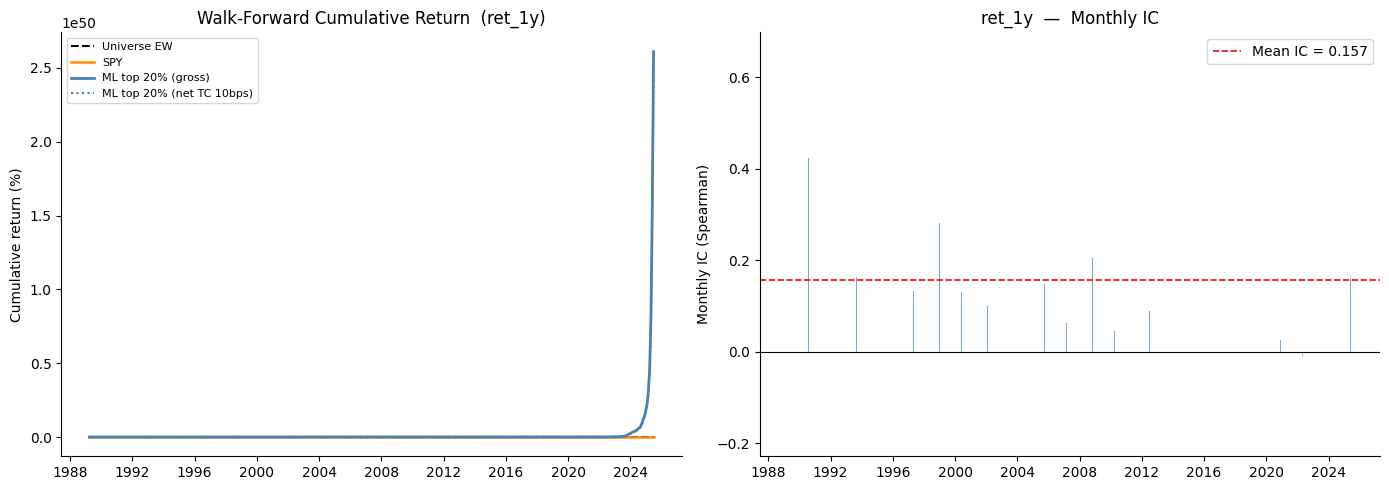

In [18]:
if not wf_results_all:
    print('No walk-forward results. Run Cell 11 first.')
else:
    targets = list(wf_results_all.keys())
    n = len(targets)
    fig, axes = plt.subplots(n, 2, figsize=(14, 5 * n))
    if n == 1:
        axes = [axes]

    for row_idx, target in enumerate(targets):
        wf       = wf_results_all[target]
        wf_idx   = wf.set_index('month')
        cum_top    = (1 + wf_idx['top_ret']).cumprod() - 1
        cum_tc     = (1 + wf_idx['tc_adj_top_ret']).cumprod() - 1
        cum_bench  = (1 + wf_idx['bench_ret']).cumprod() - 1
        spy_s      = wf_idx['spy_ret'].dropna()
        cum_spy    = (1 + spy_s).cumprod() - 1

        ax1 = axes[row_idx][0]
        ax1.plot(cum_bench.index, cum_bench * 100, 'k--',         lw=1.5, label='Universe EW')
        if not cum_spy.empty:
            ax1.plot(cum_spy.index, cum_spy * 100, color='darkorange', lw=1.8, label='SPY')
        ax1.plot(cum_top.index, cum_top * 100, color='steelblue', lw=2,
                 label=f'ML top {TOP_DECILE_PCT:.0%} (gross)')
        ax1.plot(cum_tc.index, cum_tc * 100, color='steelblue', lw=1.5, linestyle=':',
                 label=f'ML top {TOP_DECILE_PCT:.0%} (net TC {TC_BPS_ONEWAY}bps)')
        ax1.set_ylabel('Cumulative return (%)')
        ax1.set_title(f'Walk-Forward Cumulative Return  ({target})')
        ax1.legend(fontsize=8)

        ax2 = axes[row_idx][1]
        ax2.bar(wf['month'], wf['monthly_ic'],
                color=np.where(wf['monthly_ic'] >= 0, 'steelblue', 'coral'),
                alpha=0.7)
        ax2.axhline(0, color='black', lw=0.8)
        mean_ic = wf['monthly_ic'].mean()
        ax2.axhline(mean_ic, color='red', lw=1.2, linestyle='--',
                    label=f'Mean IC = {mean_ic:.3f}')
        ax2.set_ylabel('Monthly IC (Spearman)')
        ax2.set_title(f'{target}  —  Monthly IC')
        ax2.legend()

    plt.tight_layout()
    plt.show()


---
## Cell 13 — Live Scoring: Rank All Current Tickers

Apply the trained model to today's fundamentals from `pe_stats`.
Output: ranked list of tickers by predicted forward return.

In [19]:
# Use SHAP-pruned models for live scoring if available, else fall back to full models.
_live_feat_cols  = SHAP_FEATURE_COLS if 'SHAP_FEATURE_COLS' in dir() else WF_FEATURE_COLS
_live_models     = shap_models       if 'shap_models'       in dir() else models

if PRIMARY_ML_TARGET not in _live_models:
    print(f"No model for {PRIMARY_ML_TARGET}. Run Cell 9 first.")
else:
    live = get_pe_stats()
    live = live[live["market_cap_b"].notna() & (live["market_cap_b"] >= MARKET_CAP_MIN / 1e9)].copy()
    print(f"Tickers in pe_stats: {len(live):,}")

    def _col(name):
        return live[name] if name in live.columns else pd.Series(np.nan, index=live.index)

    fdf = pd.DataFrame(index=live.index)
    # Valuation multiples
    fdf["pe_ratio"]                     = _col("current_pe")
    fdf["pfcf_ratio"]                   = _col("current_pfcf")
    fdf["ev_ebitda"]                    = _col("current_evebitda")
    fdf["ps_ratio"]                     = _col("current_ps")
    fdf["pbv"]                          = _col("current_pbv")
    fdf["ptbv"]                         = _col("current_ptbv")
    fdf["fcf_yield"]                    = _col("current_fcf_yield")
    fdf["dividend_yield"]               = _col("dividend_yield")
    # Yield metrics
    fdf["earnings_yield"]               = _col("current_earnings_yield")
    fdf["earnings_yield_3y_avg"]        = _col("earnings_yield_3y_avg")
    fdf["earnings_yield_5y_avg"]        = _col("earnings_yield_5y_avg")
    fdf["fcf_yield_3y_avg"]             = _col("fcf_yield_3y_avg")
    fdf["fcf_yield_5y_avg"]             = _col("fcf_yield_5y_avg")
    fdf["ebitda_ev_yield"]              = _col("current_ebitda_ev_yield")
    fdf["ebitda_ev_yield_3y_avg"]       = _col("ebitda_ev_yield_3y_avg")
    fdf["ebitda_ev_yield_5y_avg"]       = _col("ebitda_ev_yield_5y_avg")
    # Normalized multiples
    fdf["normalized_pe_5y"]             = _col("normalized_pe_5y")
    fdf["normalized_pfcf_5y"]           = _col("normalized_pfcf_5y")
    fdf["normalized_evebitda_5y"]       = _col("normalized_evebitda_5y")
    fdf["normalized_ps_5y"]             = _col("normalized_ps_5y")
    # Quality
    fdf["roa"]                          = _col("current_roa")
    fdf["roe"]                          = _col("current_roe")
    fdf["roic"]                         = _col("current_roic")
    # Rolling medians (used in premium ratios below, not as standalone features)
    _pe_med   = _col("pe_rolling_5yr_median")
    _pfcf_med = _col("pfcf_rolling_5yr_median")
    _ev_med   = _col("evebitda_rolling_5yr_median")
    _ps_med   = _col("ps_rolling_5yr_median")
    _roa_med  = _col("roa_rolling_5yr_median")
    _roe_med  = _col("roe_rolling_5yr_median")
    _roic_med = _col("roic_rolling_5yr_median")
    _pbv_med  = _col("pbv_rolling_5yr_median")
    _ptbv_med = _col("ptbv_rolling_5yr_median")
    # Growth
    fdf["rev_cagr_1y"]  = _col("rev_growth_1yr")
    fdf["rev_cagr_3y"]  = _col("rev_cagr_3yr")
    fdf["rev_cagr_5y"]  = _col("rev_cagr_5yr")
    fdf["earn_cagr_1y"] = _col("earn_growth_1yr")
    fdf["earn_cagr_3y"] = _col("earn_cagr_3yr")
    fdf["earn_cagr_5y"] = _col("earn_cagr_5yr")
    fdf["fcf_cagr_1y"]  = _col("fcf_growth_1yr")
    fdf["fcf_cagr_3y"]  = _col("fcf_cagr_3yr")
    fdf["fcf_cagr_5y"]  = _col("fcf_cagr_5yr")
    # Profitability flag
    _eps = _col("current_eps") if "current_eps" in live.columns else _col("ttm_eps")
    fdf["is_profitable"] = (_eps > 0).astype(float)
    # Margins and leverage
    for col in ["current_gross_margin", "gross_margin_5y_median", "gross_margin_slope_5y",
                "current_operating_margin", "operating_margin_5y_median",
                "operating_margin_change_3y", "operating_margin_slope_5y",
                "current_fcf_margin", "fcf_margin_5y_median", "fcf_margin_change_3y",
                "roa_stability_5y", "debt_to_ebitda", "interest_coverage"]:
        _MAP = {
            "current_gross_margin":    "ttm_gross_margin",
            "current_operating_margin":"ttm_operating_margin",
            "current_fcf_margin":      "ttm_fcf_margin",
        }
        fdf[_MAP.get(col, col)] = _col(col)
    # Momentum: approximate from pe_stats if available, else NaN
    fdf["momentum_12_1"] = _col("momentum_12_1") if "momentum_12_1" in live.columns else np.nan

    # ── Mean-reversion premiums ───────────────────────────────────────────────
    fdf["pe_premium"]   = safe_ratio(fdf["pe_ratio"],   _pe_med)
    fdf["pfcf_premium"] = safe_ratio(fdf["pfcf_ratio"], _pfcf_med)
    fdf["ev_premium"]   = safe_ratio(fdf["ev_ebitda"],  _ev_med)
    fdf["ps_premium"]   = safe_ratio(fdf["ps_ratio"],   _ps_med)
    fdf["roa_premium"]  = safe_ratio(fdf["roa"],        _roa_med)
    fdf["roe_premium"]  = safe_ratio(fdf["roe"],        _roe_med)
    fdf["roic_premium"] = safe_ratio(fdf["roic"],       _roic_med)
    fdf["pbv_premium"]  = safe_ratio(fdf["pbv"],        _pbv_med)
    fdf["ptbv_premium"] = safe_ratio(fdf["ptbv"],       _ptbv_med)

    # ── Sector-relative features ──────────────────────────────────────────────
    _LIVE_SEC_REL = [
        ("current_pe",       True,  "pe_sector_rel"),
        ("current_pfcf",     True,  "pfcf_sector_rel"),
        ("current_evebitda", True,  "ev_sector_rel"),
        ("current_ps",       True,  "ps_sector_rel"),
        ("current_roic",     False, "roic_sector_rel"),
        ("current_roa",      False, "roa_sector_rel"),
    ]
    if "sector" in live.columns and live["sector"].notna().any():
        for src_col, positive_only, out_col in _LIVE_SEC_REL:
            if out_col not in _live_feat_cols:
                continue
            if src_col not in live.columns:
                fdf[out_col] = np.nan
                continue
            tmp  = live[["sector", src_col]].copy()
            mask = tmp["sector"].notna() & tmp[src_col].notna()
            if positive_only:
                mask = mask & (tmp[src_col] > 0)
            med  = tmp[mask].groupby("sector")[src_col].median().rename("_med")
            tmp  = tmp.join(med, on="sector")
            fdf[out_col] = safe_ratio(
                pd.Series(tmp[src_col].values, index=fdf.index),
                pd.Series(tmp["_med"].values,  index=fdf.index),
            )
    else:
        for _, _, out_col in _LIVE_SEC_REL:
            if out_col in _live_feat_cols:
                fdf[out_col] = np.nan

    # ── Cross-sectional z-score the live data ─────────────────────────────────
    X_live = fdf[_live_feat_cols].copy()
    if XSEC_ZSCORE:
        for col in _live_feat_cols:
            vals = X_live[col].dropna()
            if len(vals) > 1:
                X_live[col] = (X_live[col] - vals.mean()) / (vals.std(ddof=0) + 1e-8)

    # Impute remaining NaNs with training median (from full z-scored ML_DF)
    train_medians = ml_dated[_live_feat_cols].median() if hasattr(ml_dated, '__len__') else pd.Series(0.0, index=_live_feat_cols)
    for col in _live_feat_cols:
        X_live[col] = X_live[col].fillna(train_medians.get(col, 0))

    live["pred_ret"] = _live_models[PRIMARY_ML_TARGET].predict(X_live.values)
    live["ml_rank"]  = live["pred_ret"].rank(ascending=False).astype(int)

    display_cols = [
        "ticker", "ml_rank", "sector", "current_price", "pred_ret",
        "market_cap_b", "forward_pe", "current_roic", "current_ps", "sector_val_score",
        "current_gross_margin", "current_operating_margin", "debt_to_ebitda",
    ]
    top50 = live.nsmallest(50, "ml_rank")[
        [c for c in display_cols if c in live.columns]
    ].copy()
    top50["pred_ret_pct"] = (top50["pred_ret"] * 100).round(1)
    top50 = top50.drop(columns="pred_ret")

    feat_label = f'SHAP-pruned ({len(_live_feat_cols)} feats)' if 'SHAP_FEATURE_COLS' in dir() else f'full ({len(_live_feat_cols)} feats)'
    print(f"\nTop 50 by predicted {PRIMARY_ML_TARGET} return [{feat_label}]:")
    print(top50.round(2).to_string(index=False))


Tickers in pe_stats: 2,645



Top 50 by predicted ret_1y return [SHAP-pruned (48 feats)]:
ticker  ml_rank                 sector  current_price  market_cap_b  forward_pe  current_roic  current_ps  sector_val_score  current_gross_margin  current_operating_margin  debt_to_ebitda  pred_ret_pct
  CTEV        1             HEALTHCARE         28.340         0.470       5.080           NaN       0.480            95.700                 0.610                     0.040           0.070       260.200
  ARDT        2             HEALTHCARE          9.270         1.310       7.190         0.230       0.200            93.800                 0.500                     0.090           0.150       253.700
  STRZ        3 COMMUNICATION SERVICES         26.240         0.440         NaN        -0.150       0.350            85.300                 0.700                    -0.050           0.030       234.200
   HMY        4        BASIC MATERIALS         17.790           NaN       6.200         0.560       0.070            99.100        

---
## Cell 14 — Summary

In [20]:
print('=' * 70)
print('  FUNDAMENTALS ALPHA — SUMMARY')
print('=' * 70)
print(f'  Data:           {len(df):,} monthly observations, {df["ticker"].nunique():,} tickers')
print(f'  Market cap:     >= ${MARKET_CAP_MIN/1e6:.0f}M (micro-cap filter applied)')
print(f'  Date range:     {df["month_end_date"].min().date()} → {df["month_end_date"].max().date()}')
print(f'  Features:       {len(WF_FEATURE_COLS)} (walk-forward)  |  X-sec z-scored: {XSEC_ZSCORE}')
print(f'  Primary target: {PRIMARY_ML_TARGET}')
print()

if shap_models:
    print('── MODELS TRAINED ────────────────────────────────────────────────────')
    for target in ML_TARGETS:
        if target in shap_models:
            X_t, y_t = ml_datasets[target]
            try:
                if hasattr(X_t, 'columns'):
                    _sf = [f for f in SHAP_FEATURE_COLS if f in X_t.columns]
                    _Xp = X_t[_sf]
                else:
                    import numpy as _np2
                    _sf_idx = [i for i, f in enumerate(WF_FEATURE_COLS) if f in set(SHAP_FEATURE_COLS)]
                    _Xp = X_t[:, _sf_idx]
                preds = shap_models[target].predict(_Xp)
                r2 = 1 - np.sum((y_t - preds)**2) / np.sum((y_t - y_t.mean())**2)
            except Exception:
                r2 = float('nan')
            print(f'  {target:<10} rows={len(X_t):>7,}  eval R² (shap on full data)={r2:.3f}')

if wf_results_all:
    print()
    print('── WALK-FORWARD RESULTS ──────────────────────────────────────────────')
    rows = []
    for target, wf in wf_results_all.items():
        nw_lags  = RETURN_HORIZONS[target] - 1
        raw_icir = wf['monthly_ic'].mean() / wf['monthly_ic'].std()
        nw_icir  = newey_west_icir(wf['monthly_ic'], lags=nw_lags)
        spy_mean = wf['spy_ret'].mean()
        ex_spy   = wf['excess_vs_spy'].mean()
        rows.append({
            'horizon':   target,
            'months':    len(wf),
            'ml_top%':   f"{wf['top_ret'].mean()*100:+.2f}%",
            'net_tc':    f"{wf['tc_adj_top_ret'].mean()*100:+.2f}%",
            'univ_ew':   f"{wf['bench_ret'].mean()*100:+.2f}%",
            'spy':       f"{spy_mean*100:+.2f}%" if not np.isnan(spy_mean) else 'N/A',
            'vs_univ':   f"{wf['excess_vs_universe'].mean()*100:+.2f}%",
            'vs_univ_tc':f"{wf['tc_adj_excess'].mean()*100:+.2f}%",
            'vs_spy':    f"{ex_spy*100:+.2f}%" if not np.isnan(ex_spy) else 'N/A',
            'win_rate':  f"{(wf['excess_vs_universe'] > 0).mean():.0%}",
            'mean_ic':   f"{wf['monthly_ic'].mean():.4f}",
            'icir_raw':  f"{raw_icir:.3f}",
            'icir_nw':   f"{nw_icir:.3f}" if not np.isnan(nw_icir) else 'N/A',
            'turnover':  f"{wf['turnover'].mean():.0%}",
        })
    print(pd.DataFrame(rows).set_index('horizon').to_string())

print()
print('Notes:')
print('  - net_tc: ML top-20% after estimated TC (turnover × {:.0f}bps one-way)'.format(TC_BPS_ONEWAY))
print('  - icir_nw: Newey-West adjusted ICIR — corrects for overlapping return windows')
print('  - ICIR > 0.5 = practically significant;  > 1.0 = strong consistent factor')
print('  - Negative IC for PE/PS/EV premiums = cheaper stocks outperform (value factor)')
print('  - Positive IC for ROIC/ROE = higher quality outperforms (quality factor)')


  FUNDAMENTALS ALPHA — SUMMARY
  Data:           489,651 monthly observations, 2,582 tickers
  Market cap:     >= $300M (micro-cap filter applied)


  Date range:     1984-03-31 → 2026-06-30
  Features:       62 (walk-forward)  |  X-sec z-scored: True
  Primary target: ret_1y

── MODELS TRAINED ────────────────────────────────────────────────────
  ret_6m     rows=474,246  in-sample R²=-0.001


  ret_1y     rows=459,053  in-sample R²=-0.012
  ret_2y     rows=429,453  in-sample R²=0.007


  ret_3y     rows=400,990  in-sample R²=-0.007
  ret_5y     rows=347,909  in-sample R²=-0.060

── WALK-FORWARD RESULTS ──────────────────────────────────────────────
         months  ml_top%   net_tc  univ_ew      spy  vs_univ vs_univ_tc   vs_spy win_rate mean_ic icir_raw icir_nw turnover
horizon                                                                                                                    
ret_1y      436  +31.92%  +31.90%  +17.83%  +10.16%  +14.09%    +14.07%  +21.77%      95%  0.1567    1.029   7.186      22%

Notes:
  - net_tc: ML top-20% after estimated TC (turnover × 10bps one-way)
  - icir_nw: Newey-West adjusted ICIR — corrects for overlapping return windows
  - ICIR > 0.5 = practically significant;  > 1.0 = strong consistent factor
  - Negative IC for PE/PS/EV premiums = cheaper stocks outperform (value factor)
  - Positive IC for ROIC/ROE = higher quality outperforms (quality factor)
